In [165]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [166]:
bitcoin = pd.read_csv('BTC-EUR.csv')

In [167]:
bitcoin.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2011-10-04,3.700,3.821,3.746,3.750,3.750,1357
1,2011-10-05,3.750,3.820,3.650,3.676,3.676,3349
2,2011-10-06,3.676,3.743,3.450,3.550,3.550,6642
3,2011-10-07,3.550,3.590,2.900,3.293,3.293,7135
4,2011-10-08,3.293,3.283,2.872,2.890,2.890,2007


In [168]:
bitcoin.shape

(2923, 7)

In [169]:
bitcoin['Close']

0          3.750000
1          3.676000
2          3.550000
3          3.293000
4          2.890000
           ...     
2918    7626.029785
2919    7625.560059
2920    7655.250000
2921    7516.790039
2922    7487.083496
Name: Close, Length: 2923, dtype: float64

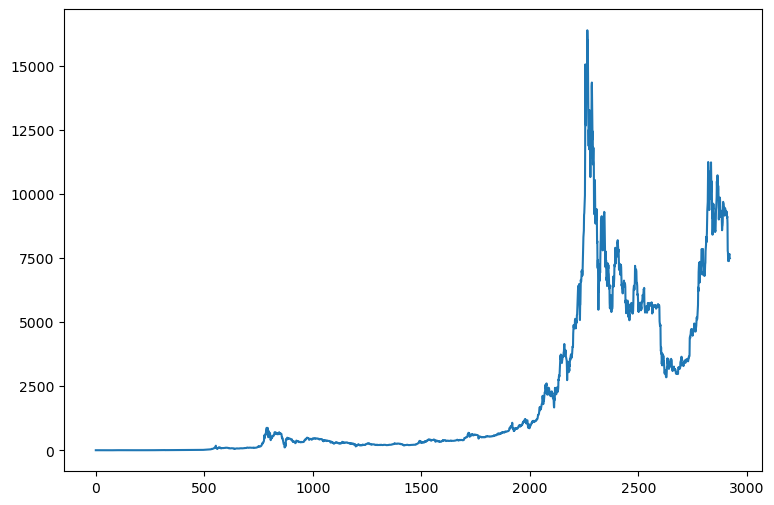

In [170]:
bitcoin['Close'].plot(figsize=(9, 6))
plt.show()

In [171]:
bitcoin = pd.read_csv('BTC-EUR.csv', index_col='Date', parse_dates=True)
bitcoin.shape

(2923, 6)

In [172]:
bitcoin.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-10-04,3.700,3.821,3.746,3.750,3.750,1357
2011-10-05,3.750,3.820,3.650,3.676,3.676,3349
2011-10-06,3.676,3.743,3.450,3.550,3.550,6642
2011-10-07,3.550,3.590,2.900,3.293,3.293,7135
2011-10-08,3.293,3.283,2.872,2.890,2.890,2007


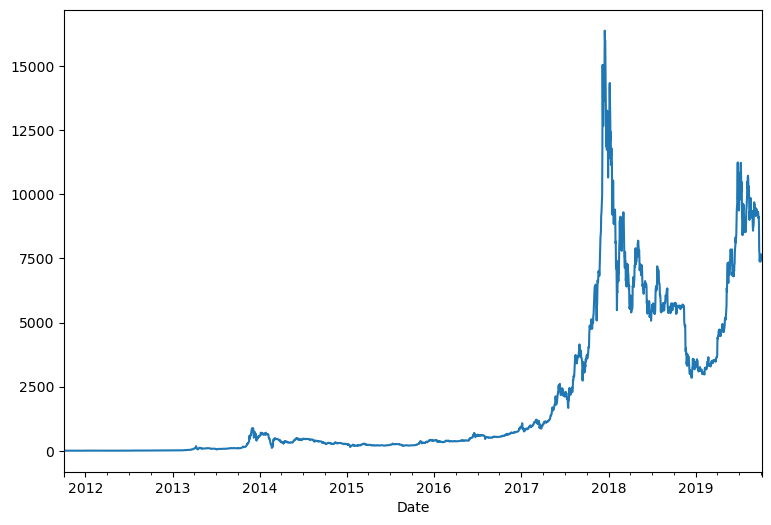

In [173]:
bitcoin['Close'].plot(figsize=(9, 6))
plt.show()

In [174]:
bitcoin.index

DatetimeIndex(['2011-10-04', '2011-10-05', '2011-10-06', '2011-10-07',
               '2011-10-08', '2011-10-09', '2011-10-10', '2011-10-11',
               '2011-10-12', '2011-10-13',
               ...
               '2019-09-25', '2019-09-26', '2019-09-27', '2019-09-28',
               '2019-09-29', '2019-09-30', '2019-10-01', '2019-10-02',
               '2019-10-03', '2019-10-04'],
              dtype='datetime64[ns]', name='Date', length=2923, freq=None)

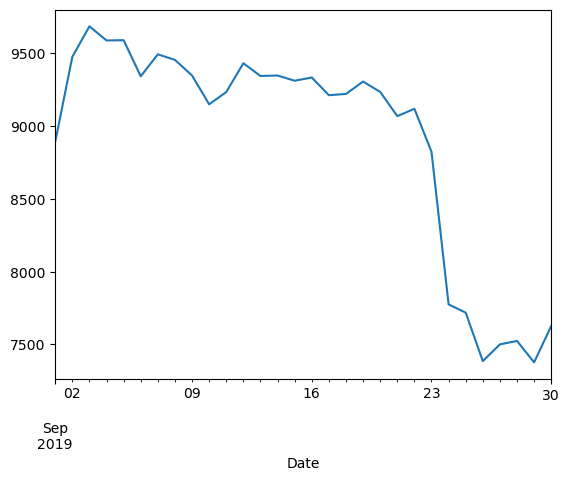

In [175]:
bitcoin.loc['2019-09','Close'].plot()
plt.show()

In [176]:
# fonction   RESAMPLE     = regruper les données selon une fréquence temporelle

In [177]:
#bitcoin.loc['2019','Close'].resample('H').plot()
#plt.show()

In [178]:
bitcoin['Close'].resample('w').agg(['mean','std','min','max'])

C:\Users\By Etienne\AppData\Local\Temp\ipykernel_8728\1803697332.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  bitcoin['Close'].resample('w').agg(['mean','std','min','max'])


,mean,std,min,max
Date,,,,
2011-10-09,3.356167,0.363120,2.890000,3.750000
2011-10-16,2.908000,0.177088,2.587000,3.090000
2011-10-23,1.910714,0.258091,1.620000,2.274000
2011-10-30,2.174000,0.244941,1.872000,2.574000
2011-11-06,2.281000,0.087130,2.170000,2.420000
...,...,...,...,...
2019-09-08,9518.921596,112.282309,9342.450195,9685.990234
2019-09-15,9309.785715,91.611734,9149.929688,9432.070313
2019-09-22,9213.828543,94.554136,9068.450195,9334.099609


In [179]:
#bitcoin['Close'].resample('w').agg(['mean','std','min','max']).plot()

In [180]:
# MOVING AVERAGE

In [181]:
bitcoin.loc['2019','Close'].rolling(window=7)

Rolling [window=7,center=False,axis=0,method=single]

<Axes: xlabel='Date'>

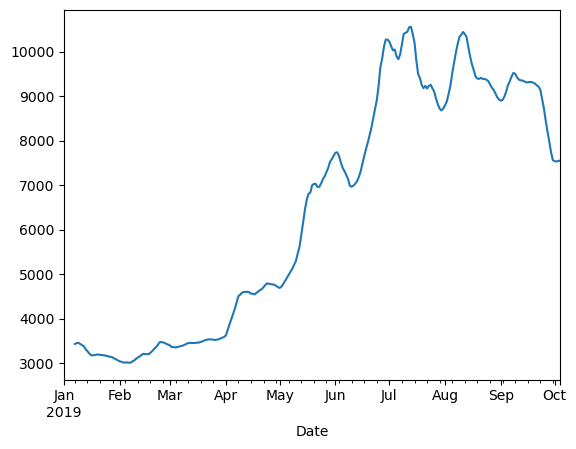

In [182]:
bitcoin.loc['2019','Close'].rolling(window=7).mean().plot()

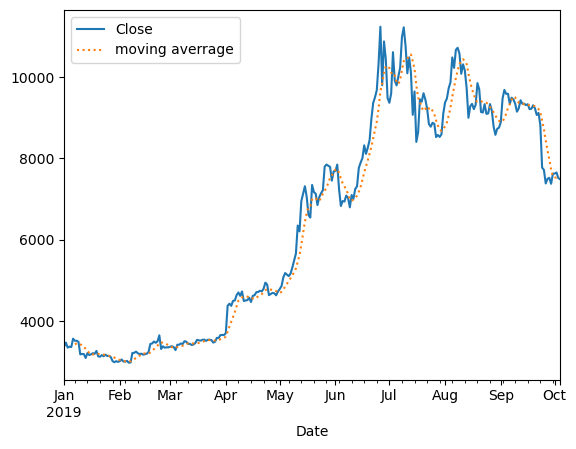

In [183]:
plt.figure()
bitcoin.loc['2019', 'Close'].plot()
bitcoin.loc['2019','Close'].rolling(window=7).mean().plot(label='moving averrage',ls=':')
plt.legend()
plt.show()

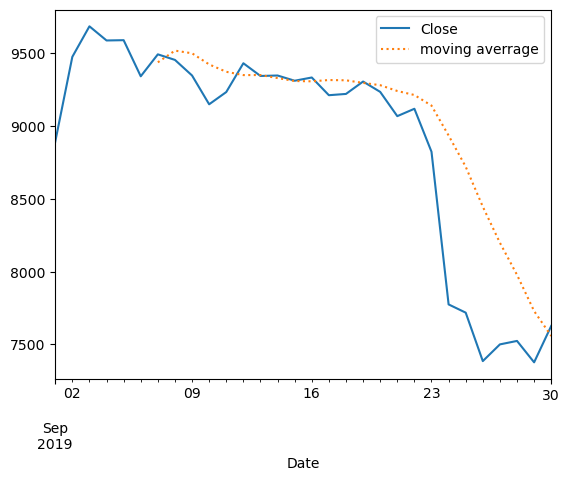

In [184]:
plt.figure()
bitcoin.loc['2019-09', 'Close'].plot()
bitcoin.loc['2019-09','Close'].rolling(window=7).mean().plot(label='moving averrage',ls=':')
plt.legend()
plt.show()

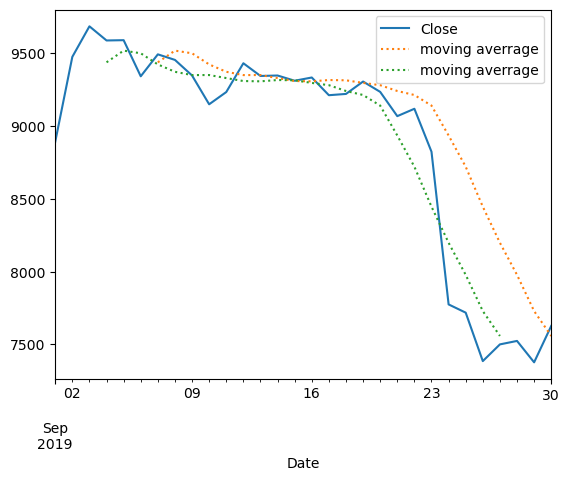

In [185]:
plt.figure()
bitcoin.loc['2019-09', 'Close'].plot()
bitcoin.loc['2019-09','Close'].rolling(window=7).mean().plot(label='moving averrage',ls=':')
bitcoin.loc['2019-09','Close'].rolling(window=7,center=True).mean().plot(label='moving averrage',ls=':')
plt.legend()
plt.show()

In [186]:
#   EXP WEIGHTED FUNCTION   = moyenne mobile exponentielle

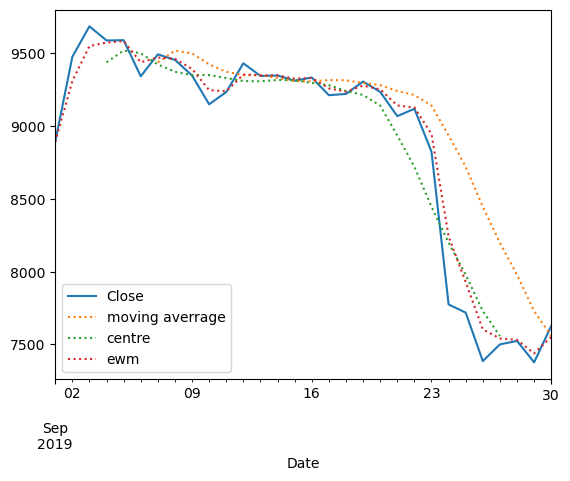

In [187]:
plt.figure()
bitcoin.loc['2019-09', 'Close'].plot()
bitcoin.loc['2019-09','Close'].rolling(window=7).mean().plot(label='moving averrage',ls=':')
bitcoin.loc['2019-09','Close'].rolling(window=7,center=True).mean().plot(label='centre',ls=':')
bitcoin.loc['2019-09','Close'].ewm(alpha=0.6).mean().plot(label='ewm',ls=':')
plt.legend()
plt.show()

In [188]:
#  ASSEMBLER DES DATA

In [189]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [190]:
bitcoin = pd.read_csv('BTC-EUR.csv', index_col='Date', parse_dates=True)

In [191]:
ethereum  = pd.read_csv('ETH-EUR.csv', index_col='Date', parse_dates=True)

<Axes: xlabel='Date'>

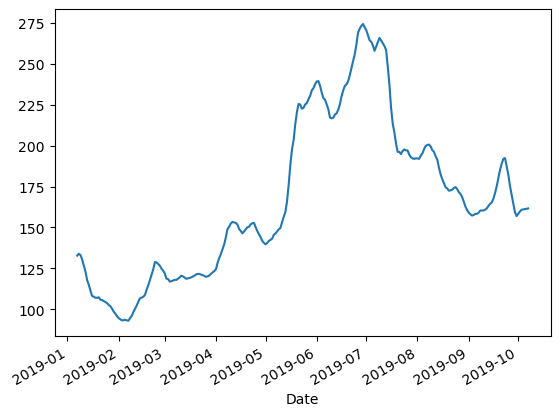

In [192]:
ethereum.loc['2019','Close'].rolling(window=7).mean().plot()

In [193]:
pd.merge(bitcoin, ethereum, on='Date', how='inner', suffixes= ('_btc','_eth'))      #inner= assemblagle sur base des index commun    #Outer=toute l etendue des index   #left    #right

,Open_btc,High_btc,Low_btc,Close_btc,Adj Close_btc,Volume_btc,Open_eth,High_eth,Low_eth,Close_eth,Adj Close_eth,Volume_eth
Date,,,,,,,,,,,,
2015-08-07,255.710007,258.880005,253.639999,256.250000,256.250000,1446808,0.593000,20.000000,0.593000,2.560000,2.560000,15200
2015-08-08,256.250000,257.029999,239.279999,240.199997,240.199997,1426996,2.560000,2.598000,0.561600,0.650000,0.650000,32816
2015-08-09,240.199997,246.110001,239.039993,243.910004,243.910004,797790,0.650000,0.800000,0.523500,0.700000,0.700000,4041
2015-08-10,243.910004,248.039993,240.779999,241.679993,241.679993,1135445,0.700000,0.750000,0.585000,0.680000,0.680000,5645
2015-08-11,241.679993,247.190002,240.399994,245.759995,245.759995,1472221,0.680000,1.008000,0.591500,0.950000,0.950000,21607
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-29,7523.009766,7541.020020,7247.169922,7375.950195,7375.950195,39755968,159.130005,159.779999,150.610001,155.160004,155.160004,7857348
2019-09-30,7375.950195,7667.890137,7075.589844,7626.029785,7626.029785,101457908,155.160004,166.649994,151.229996,165.910004,165.910004,15659055
2019-10-01,7626.029785,7818.279785,7535.799805,7625.560059,7625.560059,75644316,165.910004,170.710007,159.330002,161.410004,161.410004,11427525


In [194]:
btc_eth= pd.merge(bitcoin, ethereum, on='Date', how='inner', suffixes= ('_btc','_eth')) 

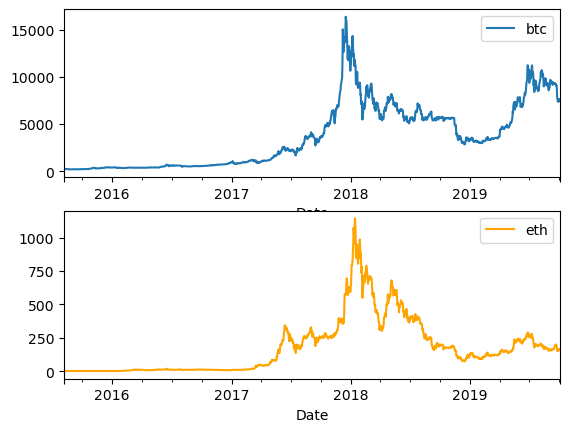

In [195]:
plt.subplot(2,1,1)
btc_eth['Close_btc'].plot(label='btc')
plt.legend()
plt.subplot(2,1,2)
btc_eth['Close_eth'].plot(c='orange',label='eth')
plt.legend()
plt.show()

In [196]:
btc_eth[['Close_btc','Close_eth']].corr()

,Close_btc,Close_eth
Close_btc,1.000000,0.791416
Close_eth,0.791416,1.000000


In [ ]:
#----------------------------------EXERCICE

In [200]:
data = bitcoin.copy()
data['Buy'] = np.zeros(len(data))
data['Sell'] = np.zeros(len(data))

In [205]:
data['RollingMax'] = data['Close'].shift(1).rolling(window=28).max()
data['RollingMin'] = data['Close'].shift(1).rolling(window=28).min()
data.loc[data['RollingMax']<data['Close'], 'Buy'] = 1
data.loc[data['RollingMin']>data['Close'], 'sell'] = -1


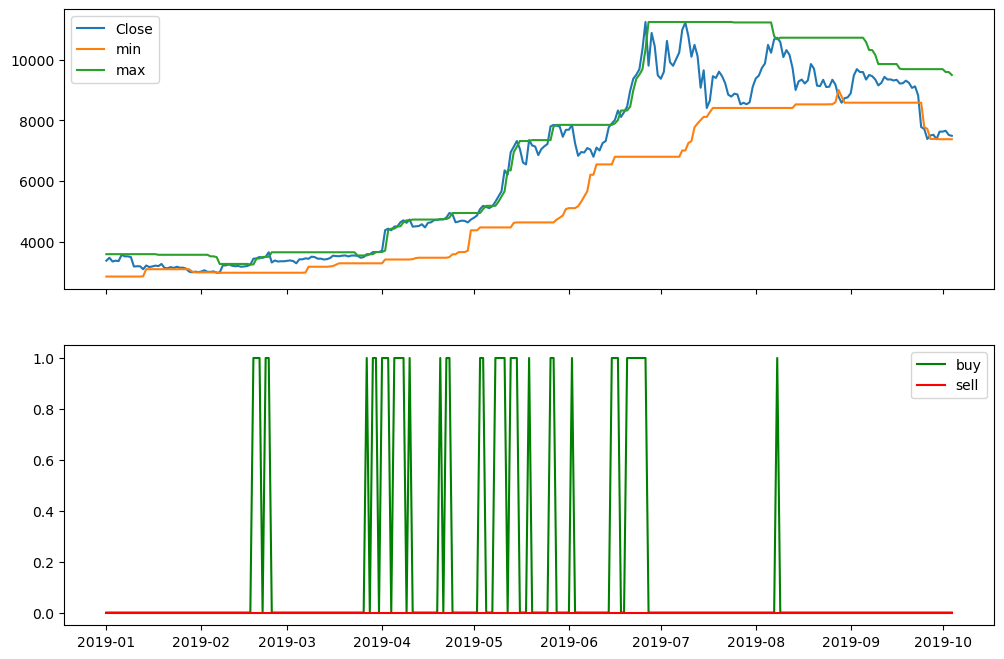

In [207]:
start = '2019'
end = '2019'
fig, ax = plt.subplots(2, figsize=(12,8),  sharex=True)
ax[0].plot(data['Close'][start:end])
ax[0].plot(data['RollingMin'][start:end])
ax[0].plot(data['RollingMax'][start:end])
ax[0].legend(['Close', 'min', 'max'])
ax[1].plot(data['Buy'][start:end], c='g')
ax[1].plot(data['Sell'][start:end], c='r')
ax[1].legend(['buy', 'sell'])